In [14]:
from huggingface_hub import snapshot_download

snapshot_download(
    repo_id="mohanty/PlantVillage",
    repo_type="dataset",
    local_dir="../data/raw/plantvillage",
    allow_patterns=[
        "data.zip",
        "leaf_grouping/leaf-map.json",
        "splits/color_train.txt",
        "splits/color_test.txt",
    ]
)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

'/Users/malaynilabh/Desktop/AI-Engineering/crop_doctor/data/raw/plantvillage'

In [1]:
from pathlib import Path

data_path = Path("../data/raw/plantvillage")

for path in data_path.rglob("*"):
    if path.is_file():
        print(path)

../data/raw/plantvillage/data.zip
../data/raw/plantvillage/leaf_grouping/leaf-map.json
../data/raw/plantvillage/splits/color_test.txt
../data/raw/plantvillage/splits/color_train.txt
../data/raw/plantvillage/.cache/huggingface/CACHEDIR.TAG
../data/raw/plantvillage/.cache/huggingface/.gitignore
../data/raw/plantvillage/.cache/huggingface/trees/9e97599868962bd0079b8db4b7f1efa9185fa1e7.json
../data/raw/plantvillage/.cache/huggingface/download/data.zip.metadata
../data/raw/plantvillage/.cache/huggingface/download/data.zip.lock
../data/raw/plantvillage/.cache/huggingface/download/leaf_grouping/leaf-map.json.metadata
../data/raw/plantvillage/.cache/huggingface/download/leaf_grouping/leaf-map.json.lock
../data/raw/plantvillage/.cache/huggingface/download/splits/color_test.txt.lock
../data/raw/plantvillage/.cache/huggingface/download/splits/color_train.txt.lock
../data/raw/plantvillage/.cache/huggingface/download/splits/color_train.txt.metadata
../data/raw/plantvillage/.cache/huggingface/downlo

In [2]:
import zipfile

zip_path = data_path / "data.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    print("Number of files:", len(z.namelist()))
    print("\nFirst 20 files:")
    
    for name in z.namelist()[:20]:
        print(name)

Number of files: 163034

First 20 files:
raw/
raw/color/
raw/color/Raspberry___healthy/
raw/color/Raspberry___healthy/6c2e049f-38c9-42c5-864f-613e6e12d59e___Mary_HL 6318.JPG
raw/color/Raspberry___healthy/d1387960-14d6-4654-ad5c-b92afa86ff6a___Mary_HL 9262.JPG
raw/color/Raspberry___healthy/fafac0a9-e5ba-420d-9dbe-034942f845b9___Mary_HL 9201.JPG
raw/color/Raspberry___healthy/a37f34f7-022d-461a-8a3d-95f5cd774e35___Mary_HL 9155.JPG
raw/color/Raspberry___healthy/fe1c1683-06cc-49c5-b86a-a41fb36f058b___Mary_HL 6249.JPG
raw/color/Raspberry___healthy/e621e3c3-842a-4489-b931-89f05c254cbe___Mary_HL 9347.JPG
raw/color/Raspberry___healthy/b8a96dea-8442-4855-9fdf-c29c9d4eca5a___Mary_HL 6398.JPG
raw/color/Raspberry___healthy/42428dcc-fefc-46dd-b209-150fbeaf4862___Mary_HL 6397.JPG
raw/color/Raspberry___healthy/076d909d-cfca-47ce-a8d1-479bb77c4bab___Mary_HL 6294.JPG
raw/color/Raspberry___healthy/27ef7a65-771c-4eab-9169-03a5fa121c71___Mary_HL 9195.JPG
raw/color/Raspberry___healthy/895d0a2d-5fda-47ca-af5

In [3]:
from pathlib import Path
import zipfile

zip_path = Path("../data/raw/plantvillage/data.zip")
extract_path = Path("../data/raw/plantvillage")

with zipfile.ZipFile(zip_path, "r") as z:

    color_files = [
        name for name in z.namelist()
        if name.startswith("raw/color/")
        and not name.endswith("/")
    ]

    print("Color images:", len(color_files))

    z.extractall(
        extract_path,
        members=color_files
    )

Color images: 54305


In [4]:
from pathlib import Path

color_path = Path("../data/raw/plantvillage/raw/color")

classes = sorted([
    p.name
    for p in color_path.iterdir()
    if p.is_dir()
])

print("Number of classes:", len(classes))

for cls in classes:
    print(cls)

Number of classes: 38
Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
Blueberry___healthy
Cherry_(including_sour)___Powdery_mildew
Cherry_(including_sour)___healthy
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___Northern_Leaf_Blight
Corn_(maize)___healthy
Grape___Black_rot
Grape___Esca_(Black_Measles)
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Grape___healthy
Orange___Haunglongbing_(Citrus_greening)
Peach___Bacterial_spot
Peach___healthy
Pepper,_bell___Bacterial_spot
Pepper,_bell___healthy
Potato___Early_blight
Potato___Late_blight
Potato___healthy
Raspberry___healthy
Soybean___healthy
Squash___Powdery_mildew
Strawberry___Leaf_scorch
Strawberry___healthy
Tomato___Bacterial_spot
Tomato___Early_blight
Tomato___Late_blight
Tomato___Leaf_Mold
Tomato___Septoria_leaf_spot
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Target_Spot
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Tomato_mosaic_virus
Tomato___he

In [5]:
class_counts = {}

for cls in classes:
    class_counts[cls] = len(
        list((color_path / cls).glob("*"))
    )

for cls, count in sorted(
    class_counts.items(),
    key=lambda x: x[1],
    reverse=True
):
    print(f"{cls:45s} {count}")

Orange___Haunglongbing_(Citrus_greening)      5507
Tomato___Tomato_Yellow_Leaf_Curl_Virus        5357
Soybean___healthy                             5090
Peach___Bacterial_spot                        2297
Tomato___Bacterial_spot                       2127
Tomato___Late_blight                          1909
Squash___Powdery_mildew                       1835
Tomato___Septoria_leaf_spot                   1771
Tomato___Spider_mites Two-spotted_spider_mite 1676
Apple___healthy                               1645
Tomato___healthy                              1591
Blueberry___healthy                           1502
Pepper,_bell___healthy                        1478
Tomato___Target_Spot                          1404
Grape___Esca_(Black_Measles)                  1383
Corn_(maize)___Common_rust_                   1192
Grape___Black_rot                             1180
Corn_(maize)___healthy                        1162
Strawberry___Leaf_scorch                      1109
Grape___Leaf_blight_(Isariopsis

In [6]:
from PIL import Image

sample_class = classes[0]

sample_image = next(
    (color_path / sample_class).glob("*")
)

image = Image.open(sample_image)

print("Image:", sample_image)
print("Format:", image.format)
print("Size:", image.size)
print("Mode:", image.mode)

Image: ../data/raw/plantvillage/raw/color/Apple___Apple_scab/14c623e5-051c-42f6-9e4f-f7a93e6a723c___FREC_Scab 2965.JPG
Format: JPEG
Size: (256, 256)
Mode: RGB


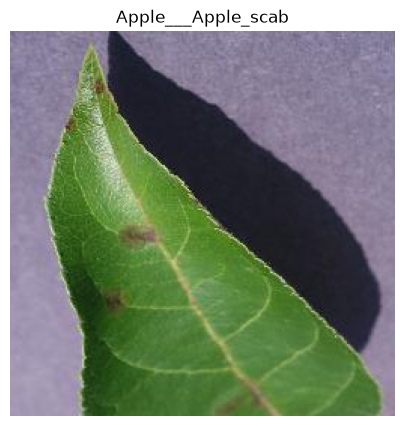

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title(sample_class)
plt.axis("off");

In [10]:
with zipfile.ZipFile(zip_path, "r") as z:

    split_files = [
        name for name in z.namelist()
        if "split" in name.lower()
        or "train" in name.lower()
        or "test" in name.lower()
    ]

    for name in split_files:
        print(name)

In [11]:
from pathlib import Path

plantvillage_path = Path("../data/raw/plantvillage")

for path in plantvillage_path.iterdir():
    print(path)

../data/raw/plantvillage/leaf_grouping
../data/raw/plantvillage/data.zip
../data/raw/plantvillage/.cache
../data/raw/plantvillage/raw
../data/raw/plantvillage/splits


In [12]:
splits_path = plantvillage_path / "splits"

if splits_path.exists():
    for path in splits_path.iterdir():
        print(path)
else:
    print("splits directory not found")

../data/raw/plantvillage/splits/color_test.txt
../data/raw/plantvillage/splits/color_train.txt


In [13]:
train_split = plantvillage_path / "splits/color_train.txt"
test_split = plantvillage_path / "splits/color_test.txt"

with open(train_split, "r") as f:
    train_lines = [line.strip() for line in f if line.strip()]

with open(test_split, "r") as f:
    test_lines = [line.strip() for line in f if line.strip()]

print("Train records:", len(train_lines))
print("Test records:", len(test_lines))

print("\nFirst 5 train records:")
for line in train_lines[:5]:
    print(line)

print("\nFirst 5 test records:")
for line in test_lines[:5]:
    print(line)

Train records: 43596
Test records: 10709

First 5 train records:
raw/color/Raspberry___healthy/a37f34f7-022d-461a-8a3d-95f5cd774e35___Mary_HL 9155.JPG
raw/color/Raspberry___healthy/368f3c83-5bd2-4906-b418-57b6ceff9bfe___Mary_HL 9160.JPG
raw/color/Raspberry___healthy/98226f66-15a1-40d5-9b62-04ae5b4fd8d5___Mary_HL 9159.JPG
raw/color/Raspberry___healthy/e2bc5cd9-a590-4b06-a610-dec52f74ae1e___Mary_HL 9163.JPG
raw/color/Raspberry___healthy/de3b86c7-8f0b-4cd8-ab11-2450fff0ec52___Mary_HL 9154.JPG

First 5 test records:
raw/color/Raspberry___healthy/6c2e049f-38c9-42c5-864f-613e6e12d59e___Mary_HL 6318.JPG
raw/color/Raspberry___healthy/8e8297fd-5e23-44f2-be98-92f7b8908f81___Mary_HL 6315.JPG
raw/color/Raspberry___healthy/67cff824-a58b-40c3-93a2-7dead429b1f0___Mary_HL 6322.JPG
raw/color/Raspberry___healthy/d20b63ce-4849-4c33-960e-74ac2ddb048c___Mary_HL 6319.JPG
raw/color/Raspberry___healthy/da1c2dba-b75e-4052-bf97-16e66fea830a___Mary_HL 6320.JPG


In [14]:
print(type(train_lines[0]))
print(train_lines[0])

<class 'str'>
raw/color/Raspberry___healthy/a37f34f7-022d-461a-8a3d-95f5cd774e35___Mary_HL 9155.JPG
